## Introducción

En el año 2024, el banco alemán **KreditSicher**, una institución financiera de tamaño mediano con más de 30 años de operación, enfrenta un proceso de transformación hacia la modernización de sus procesos crediticios. Históricamente, la aprobación de créditos en el banco se ha realizado mediante evaluaciones manuales por parte de analistas financieros. Sin embargo, ante el crecimiento del volumen de solicitudes y la necesidad de mejorar la eficiencia en la toma de decisiones, la organización busca implementar modelos de **Machine Learning** para apoyar su sistema de evaluación de riesgo crediticio.

El contexto económico actual en Europa representa un desafío para el sector bancario. Durante el último año, el aumento de las tasas de interés ha generado presión sobre los clientes y ha provocado un incremento en los incumplimientos de pago. Aunque KreditSicher no se encuentra en una situación crítica, la dirección ejecutiva ha identificado la necesidad de **reducir los niveles de morosidad sin limitar el acceso al crédito para clientes confiables**.

Adicionalmente, el banco enfrenta un desafío regulatorio importante. Una auditoría reciente reveló que, en el pasado, las decisiones de aprobación de crédito mostraban **un sesgo desfavorable hacia mujeres**, incluso cuando presentaban perfiles financieros similares a los de los hombres. Como resultado, el regulador financiero alemán exigió que cualquier nuevo sistema automatizado de evaluación crediticia garantice **criterios de equidad y transparencia**, evitando reproducir patrones de discriminación histórica.

En este contexto, el objetivo de este proyecto es desarrollar un modelo de **Machine Learning para la evaluación de riesgo crediticio** que permita:

* Identificar de manera precisa a los clientes con alto riesgo de incumplimiento.
* Garantizar un tratamiento justo en las decisiones crediticias, independientemente del género del solicitante.
* Proporcionar explicaciones claras y comprensibles sobre las decisiones del modelo, cumpliendo con los requisitos regulatorios.

Este proyecto busca demostrar cómo las herramientas de **Ciencia de Datos y aprendizaje automático** pueden contribuir a mejorar la toma de decisiones financieras, equilibrando **precisión predictiva, equidad algorítmica y transparencia**.


# Descripción de los datos.

### Información Financiera y del Préstamo
* **CheckingStatus:** Estado de la cuenta corriente del cliente. Indica si tiene saldo, si está en números rojos o si ni siquiera tiene una cuenta en el banco.
* **LoanDuration:** Duración del préstamo expresada en **meses**.
* **LoanAmount:** Monto total del crédito solicitado.
* **InstallmentPercent:** Tasa de cuotas en relación con los ingresos disponibles del cliente (qué porcentaje de su sueldo se va en pagar el crédito).
* **InstallmentPlans:** Planes de pago a plazos externos (por ejemplo, si tiene deudas en otras tiendas o bancos).
* **ExistingCreditsCount:** Número de créditos que el cliente ya tiene abiertos en este banco.

### Historial y Comportamiento
* **CreditHistory:** Estado del historial crediticio previo (si ha pagado a tiempo, si ha tenido retrasos críticos o si ya ha liquidado otros créditos con éxito).
* **LoanPurpose:** El motivo del préstamo (comprar un coche, muebles, educación, reparaciones, etc.).
* **ExistingSavings:** Saldo en la cuenta de ahorros o bonos del cliente.

### Perfil Demográfico y Laboral
* **Sex:** Sexo del solicitante (a menudo combinado con el estado civil en este dataset original).
* **Age:** Edad del solicitante en años.
* **EmploymentDuration:** Tiempo que el cliente lleva trabajando en su empleo actual.
* **Job:** Categoría laboral (desempleado, no cualificado, cualificado, o altamente cualificado/autónomo).
* **Dependents:** Número de personas que dependen económicamente del solicitante.
* **ForeignWorker:** Indica si el solicitante es un trabajador extranjero (variable binaria).

### Vivienda y Activos
* **CurrentResidenceDuration:** Tiempo (generalmente en años) que el cliente ha vivido en su domicilio actual.
* **OwnsProperty:** El activo más valioso que posee el cliente (bienes raíces, seguro de vida, coche, etc.).
* **Housing:** Tipo de vivienda en la que reside (propia, alquilada o gratuita/proporcionada por la empresa).

### Otros Datos
* **OthersOnLoan:** Indica si hay otros avalistas o solicitantes conjuntos en el préstamo.
* **Telephone:** Si el cliente tiene un teléfono registrado a su nombre (indicador de estabilidad en la época en que se creó el dataset).

### Clasificación
- **Risk**: Representa la clasificación final del cliente según su comportamiento de pago histórico. Esta es la variable objetivo.

# Importacion de librerias

In [39]:
# Importamos librerias
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import missingno as msno
import pandas.api.types as ptypes
from IPython.display import display, Markdown

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score, roc_auc_score, roc_curve, confusion_matrix

# Exploracion de datos


In [5]:
# Creamos un df para los datos
df = pd.read_csv('data/german_credit_data_biased_training.csv')
print(df.head(5))

  CheckingStatus  LoanDuration           CreditHistory LoanPurpose  \
0       0_to_200            31    credits_paid_to_date       other   
1         less_0            18    credits_paid_to_date     car_new   
2         less_0            15  prior_payments_delayed   furniture   
3       0_to_200            28    credits_paid_to_date  retraining   
4    no_checking            28  prior_payments_delayed   education   

   LoanAmount ExistingSavings EmploymentDuration  InstallmentPercent     Sex  \
0        1889      100_to_500             less_1                   3  female   
1         462        less_100             1_to_4                   2  female   
2         250        less_100             1_to_4                   2    male   
3        3693        less_100          greater_7                   3    male   
4        6235     500_to_1000          greater_7                   3    male   

  OthersOnLoan  ...       OwnsProperty Age  InstallmentPlans Housing  \
0         none  ...  savin

In [6]:
# Tipo de datos de cada columna
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   CheckingStatus            5000 non-null   str  
 1   LoanDuration              5000 non-null   int64
 2   CreditHistory             5000 non-null   str  
 3   LoanPurpose               5000 non-null   str  
 4   LoanAmount                5000 non-null   int64
 5   ExistingSavings           5000 non-null   str  
 6   EmploymentDuration        5000 non-null   str  
 7   InstallmentPercent        5000 non-null   int64
 8   Sex                       5000 non-null   str  
 9   OthersOnLoan              5000 non-null   str  
 10  CurrentResidenceDuration  5000 non-null   int64
 11  OwnsProperty              5000 non-null   str  
 12  Age                       5000 non-null   int64
 13  InstallmentPlans          5000 non-null   str  
 14  Housing                   5000 non-null   str  
 15

In [7]:
# Conteo de NaN
print(df.isna().sum())

CheckingStatus              0
LoanDuration                0
CreditHistory               0
LoanPurpose                 0
LoanAmount                  0
ExistingSavings             0
EmploymentDuration          0
InstallmentPercent          0
Sex                         0
OthersOnLoan                0
CurrentResidenceDuration    0
OwnsProperty                0
Age                         0
InstallmentPlans            0
Housing                     0
ExistingCreditsCount        0
Job                         0
Dependents                  0
Telephone                   0
ForeignWorker               0
Risk                        0
dtype: int64


In [8]:
# Valores unicos
for column in df:
  print(df[column].unique())
  print()

<StringArray>
['0_to_200', 'less_0', 'no_checking', 'greater_200']
Length: 4, dtype: str

[31 18 15 28 32  9 16 11 35  5 27 29  4 33 39 13 34 23 10 25 20 26 21  7
 14 64  6 19 17 38  8 30 22 37 12 36 50 41 24 43 40 48 46 44 42 45 53 61
 51 63 47 54 49 60 59 56 62 57 52]

<StringArray>
[  'credits_paid_to_date', 'prior_payments_delayed',     'outstanding_credit',
  'all_credits_paid_back',             'no_credits']
Length: 5, dtype: str

<StringArray>
[     'other',    'car_new',  'furniture', 'retraining',  'education',
   'vacation', 'appliances',   'car_used',    'repairs',   'radio_tv',
   'business']
Length: 11, dtype: str

[1889  462  250 ... 6536 1597 4152]

<StringArray>
['100_to_500', 'less_100', '500_to_1000', 'unknown', 'greater_1000']
Length: 5, dtype: str

<StringArray>
['less_1', '1_to_4', 'greater_7', '4_to_7', 'unemployed']
Length: 5, dtype: str

[3 2 6 5 4 1]

<StringArray>
['female', 'male']
Length: 2, dtype: str

<StringArray>
['none', 'co-applicant', 'guarantor']
Len

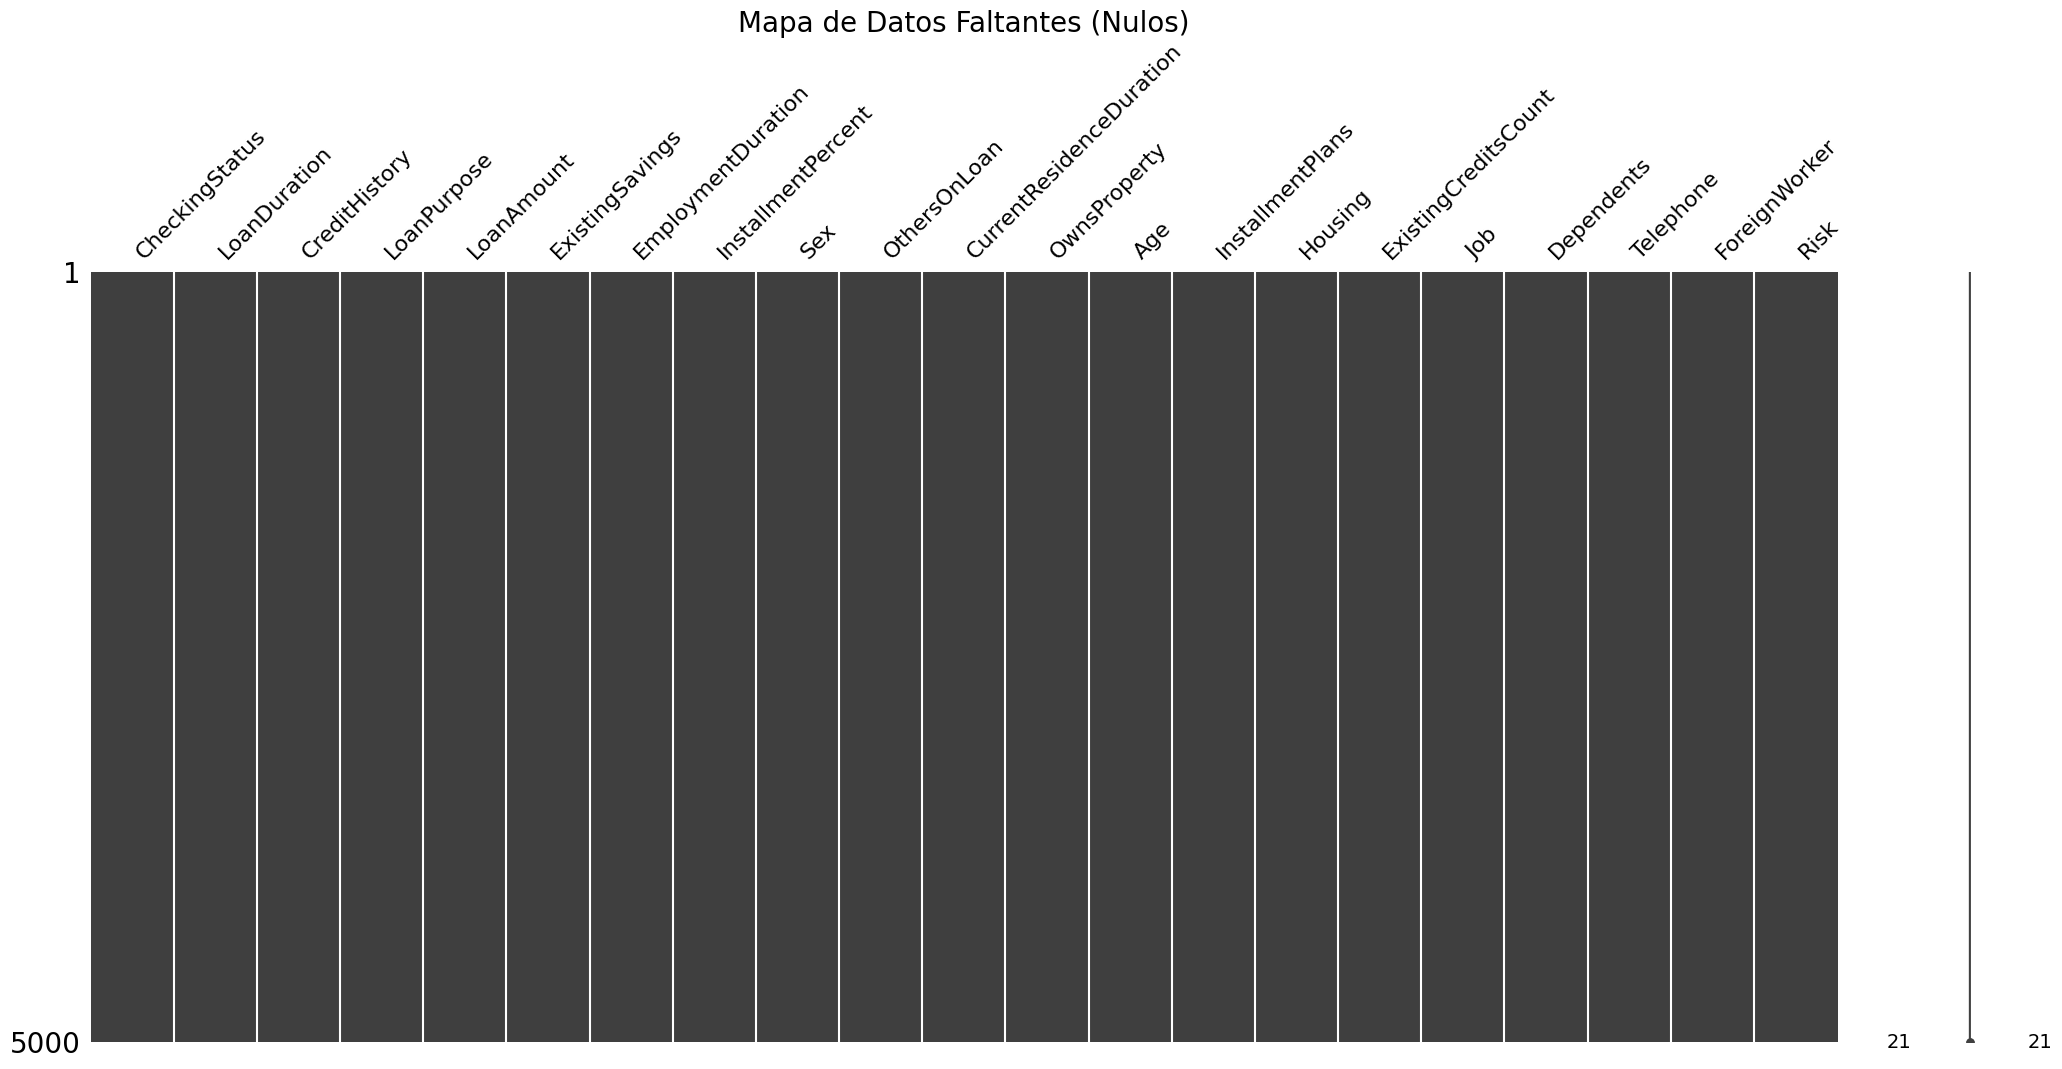

In [9]:
# Mapa de calor de TODOS los datos faltantes (Detecta nulos en todo el DF)
msno.matrix(df)
plt.title("Mapa de Datos Faltantes (Nulos)", fontsize=20)
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_11132\3832605572.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


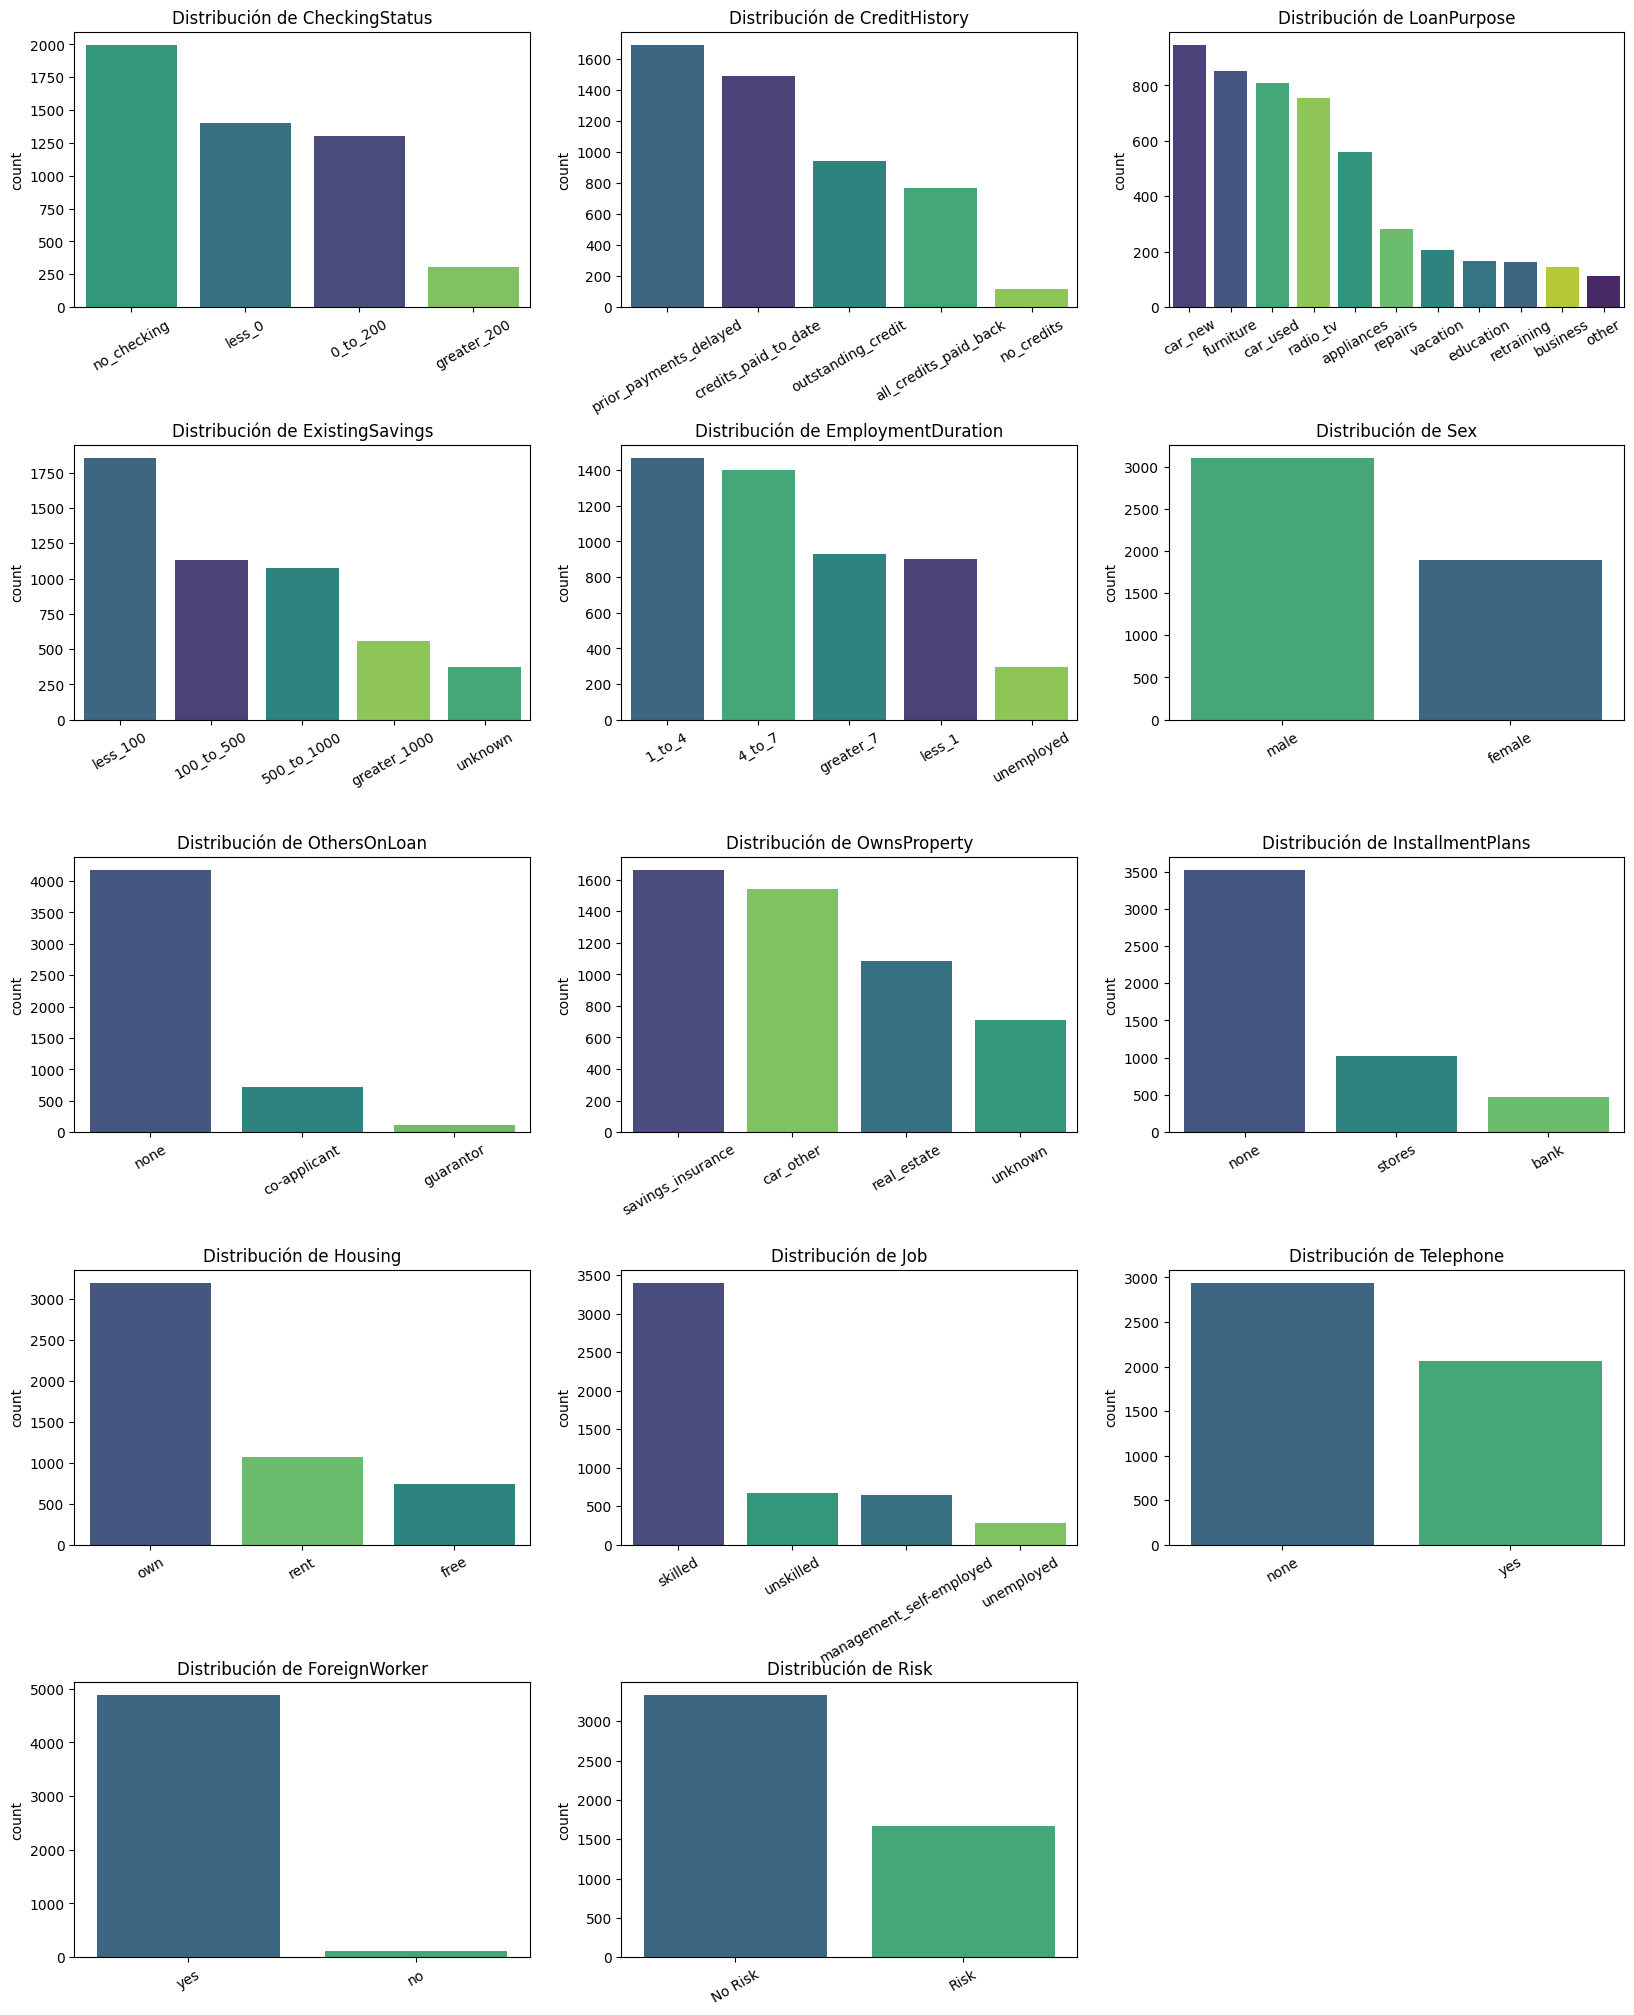

In [10]:
#Filtramos solo las columnas de tipo objeto (strings)
categorical_cols = df.select_dtypes(include=['object']).columns
plt.figure(figsize=(20, 25))
plt.subplots_adjust(hspace=0.5)

# Creamos un gráfico para cada variable
for i, col in enumerate(categorical_cols):
    plt.subplot(len(categorical_cols) // 3 + 1, 3, i + 1)
    sns.countplot(data=df, x=col, palette='viridis', order=df[col].value_counts().index, hue=col, legend=False)
    plt.title(f'Distribución de {col}')
    plt.xticks(rotation=30) # Rotamos las etiquetas para que no se amontonen
    plt.xlabel('')

plt.show()

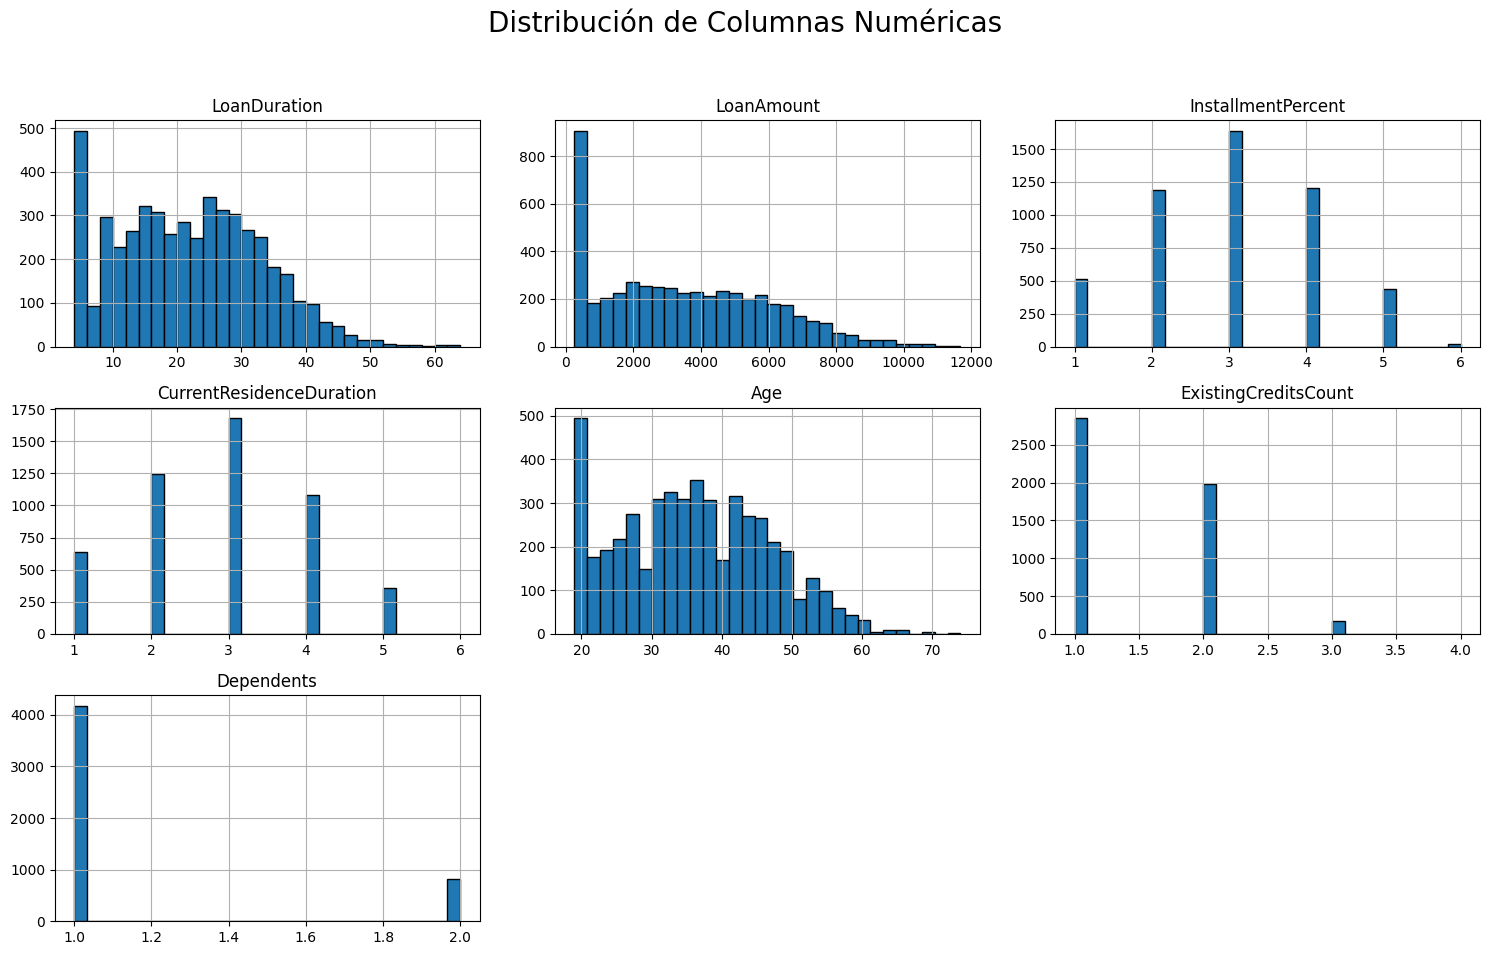

In [11]:
# Histogramas de todas las columnas numéricas
df.hist(figsize=(15, 10), bins=30, edgecolor='black')
plt.suptitle("Distribución de Columnas Numéricas", fontsize=20)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

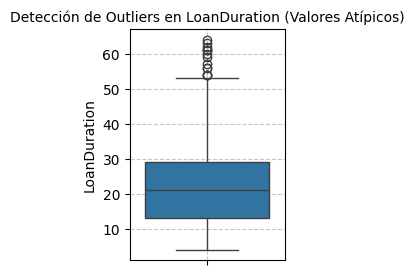

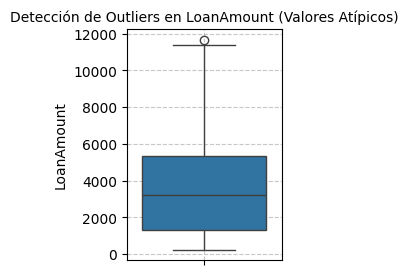

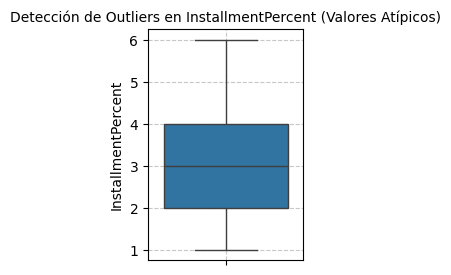

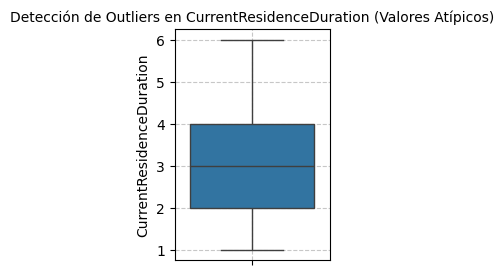

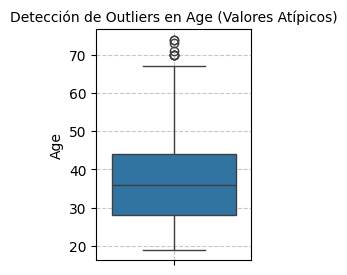

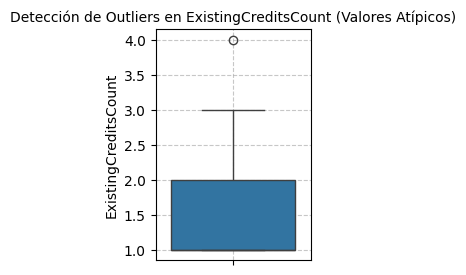

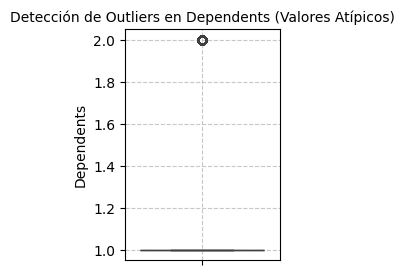

In [12]:
# Boxplots de todas las columnas numéricas (Para ver Outliers)
for column in df:
  # Check if the column is of a numeric data type
  if ptypes.is_numeric_dtype(df[column]):
    plt.figure(figsize=(2, 3))
    # Pass the Series directly to boxplot
    sns.boxplot(data=df, y=column)
    plt.xticks(rotation=45)
    plt.title(f"Detección de Outliers en {column} (Valores Atípicos)", fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
  else:
    None

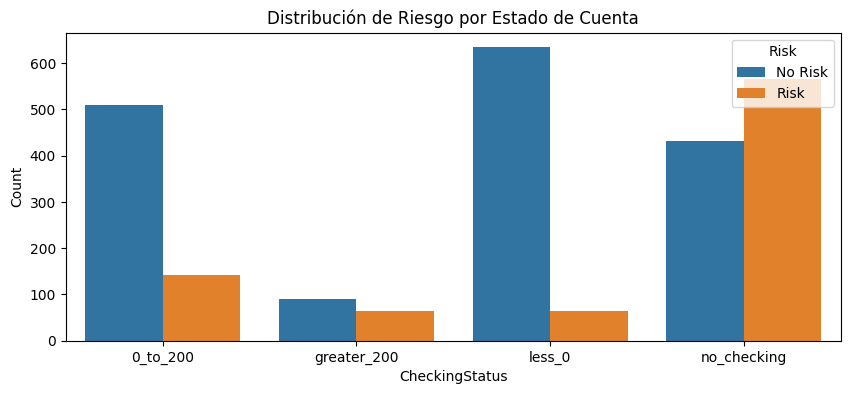

In [13]:
# Agrupamos por la variables y contamos el numero de combinaciones
df_2 = df.groupby(['Risk','Sex', 'CheckingStatus']).size()

# Convertir tu serie en un DataFrame plano para graficar
df_plot = df_2.reset_index()
df_plot.columns = ['Risk', 'Sex', 'CheckingStatus', 'Count']

# Gráfico de barras comparativo
plt.figure(figsize=(10, 4))
sns.barplot(data=df_plot, x='CheckingStatus', y='Count', hue='Risk', errorbar=None)
plt.title('Distribución de Riesgo por Estado de Cuenta')
plt.show()

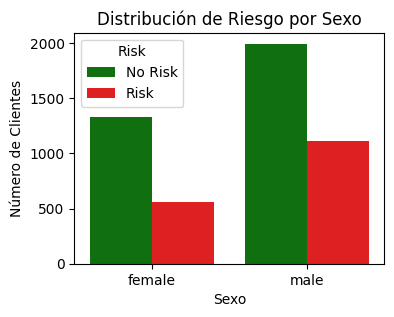

In [14]:
# Agrupamos por las variables 'Risk' y 'Sex' y contamos el número de combinaciones
df_sex_risk = df.groupby(['Risk', 'Sex']).size().reset_index(name='Count')

# Gráfico de barras comparativo de Riesgo por Sexo
plt.figure(figsize=(4, 3))
sns.barplot(data=df_sex_risk, x='Sex', y='Count', hue='Risk', errorbar=None, palette={'No Risk': 'green', 'Risk': 'red'})
plt.title('Distribución de Riesgo por Sexo')
plt.xlabel('Sexo')
plt.ylabel('Número de Clientes')
plt.show()

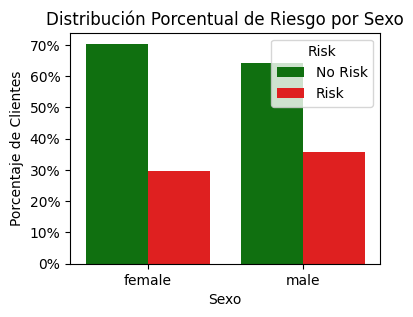

In [15]:
# Agrupamos por las variables 'Risk' y 'Sex' y contamos el número de combinaciones
df_sex_risk = df.groupby(['Risk', 'Sex']).size().reset_index(name='Count')

# Calculamos el porcentaje dentro de cada sexo
df_sex_risk['Percentage'] = df_sex_risk.groupby('Sex')['Count'].transform(lambda x: x / x.sum() * 100)

# Gráfico de barras comparativo de Riesgo por Sexo mostrando porcentajes
plt.figure(figsize=(4, 3))
sns.barplot(data=df_sex_risk, x='Sex', y='Percentage', hue='Risk', errorbar=None, palette={'No Risk': 'green', 'Risk': 'red'})
plt.title('Distribución Porcentual de Riesgo por Sexo')
plt.xlabel('Sexo')
plt.ylabel('Porcentaje de Clientes')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())
plt.show()

**Data Quality Assessment — Hallazgos**

El dataset cuenta con 5,000 registros y 21 columnas sin valores nulos. Los tipos de datos son consistentes con lo esperado. Sin embargo, se identificaron valores `unknown` en las columnas `ExistingSavings` (7%) y `OwnsProperty` (14%), que no representan datos faltantes sino una categoría propia que requiere tratamiento en el preprocesamiento.

Se identificaron dos columnas con baja utilidad predictiva:
- `ForeignWorker`: 98% de los registros corresponden a trabajadores extranjeros, ofreciendo poca variabilidad
- `Telephone`: sin relación clara con el riesgo crediticio

Sobre el perfil general del solicitante, la mayoría presenta señales de fragilidad financiera: bajos niveles de ahorro, cuentas corrientes en negativo o inexistentes, e historial crediticio con pagos aplazados. A pesar de esto, el 67% fue clasificado como No Risk, sugiriendo que otros factores compensan dicha fragilidad.

Finalmente, el análisis por género muestra que proporcionalmente las mujeres reciben una mayor tasa de aprobación (70%) que los hombres (64%), aunque se investigará si variables correlacionadas con género introducen sesgo indirecto en el modelo.

# Desarrollo de modelo predictivo.


## Eliminación de columnas innecesarias para el modelo


In [16]:
df_drop_columns = df.drop('ForeignWorker', axis=1)
df_drop_columns.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   CheckingStatus            5000 non-null   str  
 1   LoanDuration              5000 non-null   int64
 2   CreditHistory             5000 non-null   str  
 3   LoanPurpose               5000 non-null   str  
 4   LoanAmount                5000 non-null   int64
 5   ExistingSavings           5000 non-null   str  
 6   EmploymentDuration        5000 non-null   str  
 7   InstallmentPercent        5000 non-null   int64
 8   Sex                       5000 non-null   str  
 9   OthersOnLoan              5000 non-null   str  
 10  CurrentResidenceDuration  5000 non-null   int64
 11  OwnsProperty              5000 non-null   str  
 12  Age                       5000 non-null   int64
 13  InstallmentPlans          5000 non-null   str  
 14  Housing                   5000 non-null   str  
 15

## Regresion Logistica

### División en conjuntos de entrenamiento y prueba

In [17]:


# Definir las características (X) y la variable objetivo (y)
X = df_drop_columns.drop('Risk', axis=1) # Todas las columnas excepto 'Risk'
y = df_drop_columns['Risk'] # La columna 'Risk' es nuestra variable objetivo

# Dividir los datos en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Imprimir las dimensiones de los conjuntos resultantes
print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test: {X_test.shape}")
print(f"Dimensiones de y_train: {y_train.shape}")
print(f"Dimensiones de y_test: {y_test.shape}")

Dimensiones de X_train: (4000, 19)
Dimensiones de X_test: (1000, 19)
Dimensiones de y_train: (4000,)
Dimensiones de y_test: (1000,)


### Transformación de características categóricas en numéricas.

### Conjunto de entrenamiento.

### Codificación One-Hot con Selección Manual de Categorías Base

Para asegurar una interpretación más lógica de los coeficientes del modelo de Regresión Logística, vamos a realizar el One-Hot Encoding especificando manualmente la categoría base para cada variable. Esto nos permitirá comparar el impacto de cada categoría con una referencia significativa, en lugar de que `drop_first=True` elimine una categoría arbitrariamente (generalmente la primera en orden alfabético).

**Estrategia para la selección de categorías base:**
Se seleccionarán categorías que representen, en general, un estado 'favorable' o 'neutral' para el riesgo crediticio, de modo que los coeficientes de las demás categorías se interpreten como el impacto *adicional* (positivo para riesgo, negativo para no riesgo) en comparación con esa base.

Por ejemplo:
-   **CheckingStatus:** `greater_200` (saldo más favorable)
-   **CreditHistory:** `all_credits_paid_back` (historial perfecto)
-   **ExistingSavings:** `greater_1000` (ahorros más altos)
-   **EmploymentDuration:** `greater_7` (mayor estabilidad laboral)
-   **Sex:** `female` (para observar el impacto de ser 'male' en relación con 'female' debido al sesgo identificado)
-   **OwnsProperty:** `real_estate` (activo más sólido)
-   **Job:** `management_self-employed` (categoría laboral de mayor nivel)

Esta re-codificación nos permitirá reinterpretar los coeficientes del modelo de regresión logística con mayor claridad y detectar si los resultados contraintuitivos persisten o se clarifican.

In [18]:
# Definir manualmente las categorías base para cada variable categórica.
# Estas son las columnas que se eliminarán después de crear las dummies.
base_categories = {
    'CheckingStatus': 'CheckingStatus_greater_200',
    'CreditHistory': 'CreditHistory_all_credits_paid_back',
    'LoanPurpose': 'LoanPurpose_other', # Elegimos 'other' como neutral/general
    'ExistingSavings': 'ExistingSavings_greater_1000',
    'EmploymentDuration': 'EmploymentDuration_greater_7',
    'Sex': 'Sex_female', # Base para el análisis de sesgo de género
    'OthersOnLoan': 'OthersOnLoan_none', # Sin co-solicitantes/garantes
    'OwnsProperty': 'OwnsProperty_real_estate',
    'InstallmentPlans': 'InstallmentPlans_none',
    'Housing': 'Housing_own',
    'Job': 'Job_management_self-employed',
    'Telephone': 'Telephone_yes'
}

# Obtener la lista de columnas categóricas de todo el DataFrame original (excluyendo 'Risk')
# Esto asegura que el encoding se aplica consistentemente en train y test, incluso si una categoría
# no aparece en uno de los splits.
categorical_cols_from_original_df = df_drop_columns.select_dtypes(include='object').columns.drop('Risk').tolist()

print("Categorías base definidas y columnas categóricas identificadas.")

Categorías base definidas y columnas categóricas identificadas.


C:\Users\HP\AppData\Local\Temp\ipykernel_11132\59118916.py:21: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols_from_original_df = df_drop_columns.select_dtypes(include='object').columns.drop('Risk').tolist()


In [19]:
X_train_encoded = X_train.copy()
# Invertir el mapeo de la variable objetivo 'Risk'
y_train_encoded = y_train.map({'Risk': 0, 'No Risk': 1})

# Identificar columnas categóricas (tipo 'object')
categorical_cols = X_train_encoded.select_dtypes(include='object').columns.tolist()

# Aplicar One-Hot Encoding a las columnas categóricas (sin drop_first=True inicialmente)
X_train_encoded = pd.get_dummies(X_train_encoded, columns=categorical_cols)

# Eliminar manualmente las columnas de las categorías base
columns_to_drop_train = [col for col in base_categories.values() if col in X_train_encoded.columns]
X_train_encoded = X_train_encoded.drop(columns=columns_to_drop_train, errors='ignore')

print("Entrenamiento después del encoding:")
print(X_train_encoded.head())
print(f"Nueva forma del Entrenamiento: {X_train_encoded.shape}")

print("Objetivo del Entrenamiento después del encoding:")
print(y_train_encoded.head())
print(f"Nueva forma del Objetivo del Entrenamiento: {y_train_encoded.shape}")

Entrenamiento después del encoding:
      LoanDuration  LoanAmount  InstallmentPercent  CurrentResidenceDuration  \
964             31        1098                   3                         4   
4275            13        3797                   4                         1   
730             29        3351                   3                         5   
1711            31        5822                   4                         3   
1329            21        2573                   3                         3   

      Age  ExistingCreditsCount  Dependents  CheckingStatus_0_to_200  \
964    19                     1           2                     True   
4275   38                     2           1                    False   
730    49                     2           2                    False   
1711   39                     2           2                    False   
1329   28                     1           1                     True   

      CheckingStatus_less_0  CheckingStatus_no_che

C:\Users\HP\AppData\Local\Temp\ipykernel_11132\920953379.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train_encoded.select_dtypes(include='object').columns.tolist()


### Conjunto de prueba.

In [20]:
X_test_encoded = X_test.copy()
# Invertir el mapeo de la variable objetivo 'Risk'
y_test_encoded = y_test.map({'Risk': 0, 'No Risk': 1})

# Identificar columnas categóricas (tipo 'object')
categorical_cols = X_test_encoded.select_dtypes(include='object').columns.tolist()

# Aplicar One-Hot Encoding a las columnas categóricas (sin drop_first=True inicialmente)
X_test_encoded = pd.get_dummies(X_test_encoded, columns=categorical_cols)

# Eliminar manualmente las columnas de las categorías base
columns_to_drop_test = [col for col in base_categories.values() if col in X_test_encoded.columns]
X_test_encoded = X_test_encoded.drop(columns=columns_to_drop_test, errors='ignore')

# Asegurar que X_test_encoded tenga las mismas columnas que X_train_encoded
# Esto es crucial para la consistencia entre los conjuntos de entrenamiento y prueba
missing_cols_in_test = set(X_train_encoded.columns) - set(X_test_encoded.columns)
for c in missing_cols_in_test:
    X_test_encoded[c] = 0
# Asegurar que el orden de las columnas sea el mismo
X_test_encoded = X_test_encoded[X_train_encoded.columns]

print("Prueba después del encoding:")
print(X_test_encoded.head())
print(f"Nueva forma del Prueba: {X_test_encoded.shape}")

print("Objetivo del Prueba después del encoding:")
print(y_test_encoded.head())
print(f"Nueva forma del Objetivo del Prueba: {y_test_encoded.shape}")

Prueba después del encoding:
      LoanDuration  LoanAmount  InstallmentPercent  CurrentResidenceDuration  \
2440            26        2733                   3                         1   
1480            14        4162                   2                         4   
4162            19         402                   2                         3   
4551            31        4568                   5                         5   
52               8         250                   3                         3   

      Age  ExistingCreditsCount  Dependents  CheckingStatus_0_to_200  \
2440   25                     1           1                    False   
1480   34                     1           1                    False   
4162   24                     1           1                    False   
4551   49                     2           1                    False   
52     46                     2           2                    False   

      CheckingStatus_less_0  CheckingStatus_no_checking  

C:\Users\HP\AppData\Local\Temp\ipykernel_11132\132929209.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_test_encoded.select_dtypes(include='object').columns.tolist()


### Matriz de Correlacion Conjunto de entrenamiento

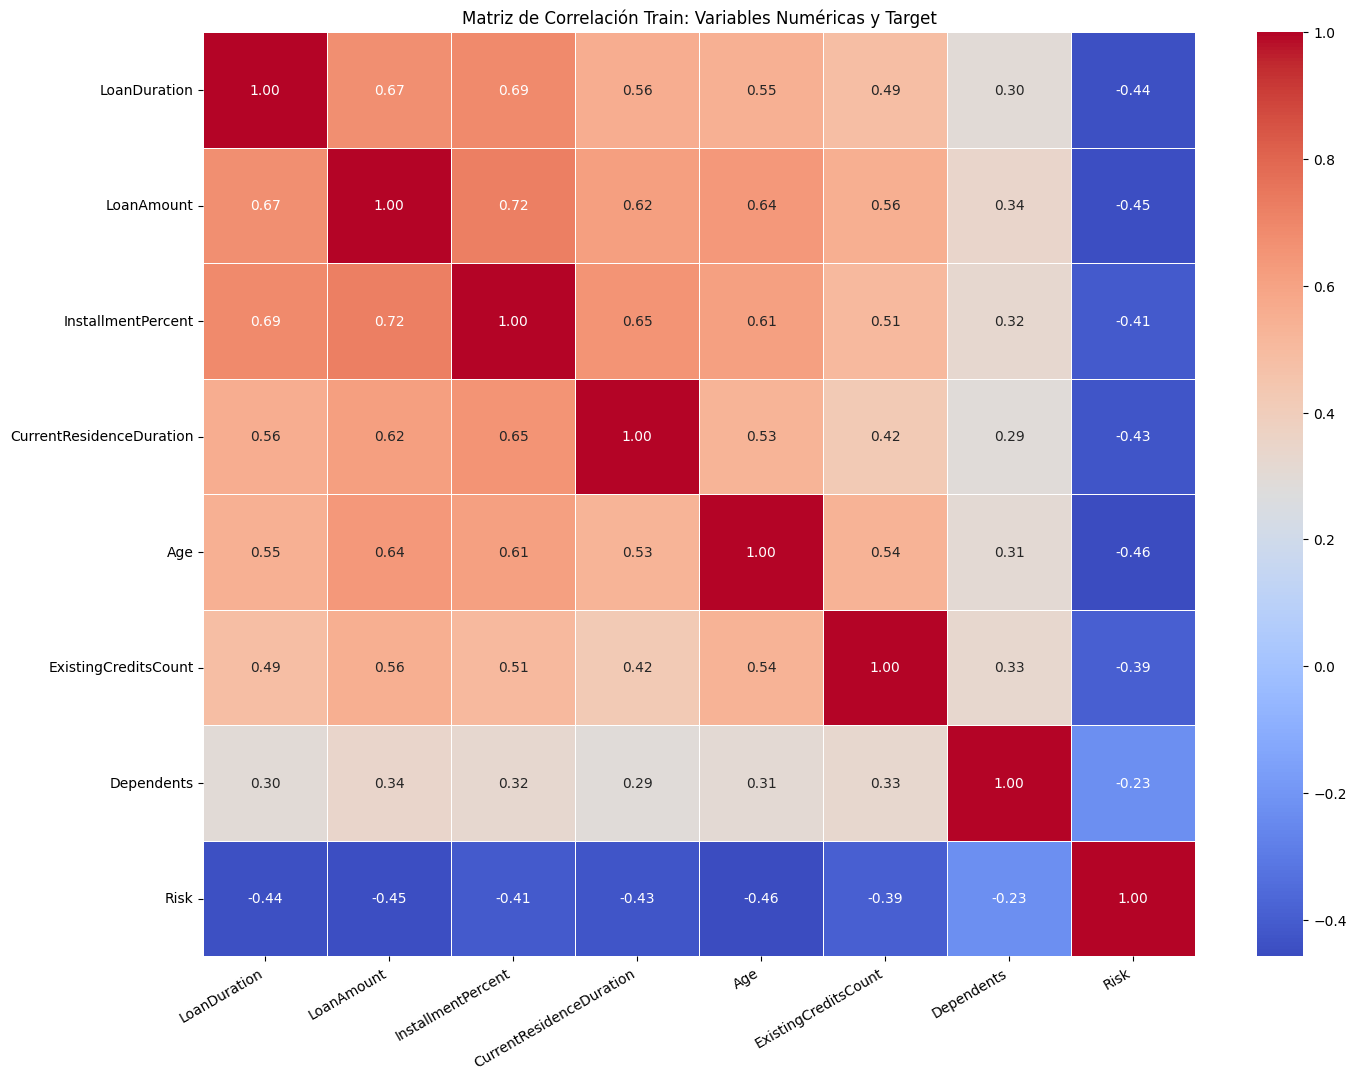

In [21]:
# Combinamos features y target
combined_df_encoded_train = pd.concat([X_train_encoded, y_train_encoded], axis=1)

# Seleccionamos solo las columnas numéricas (que ahora incluirán el target)
numeric_cols_train = combined_df_encoded_train.select_dtypes(include=['int64', 'float64'])

# Calculamos la matriz de correlación
corr_matrix = numeric_cols_train.corr()

# Dibujamos el heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación Train: Variables Numéricas y Target')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.show()

### Matriz de Correlacion Conjunto de prueba

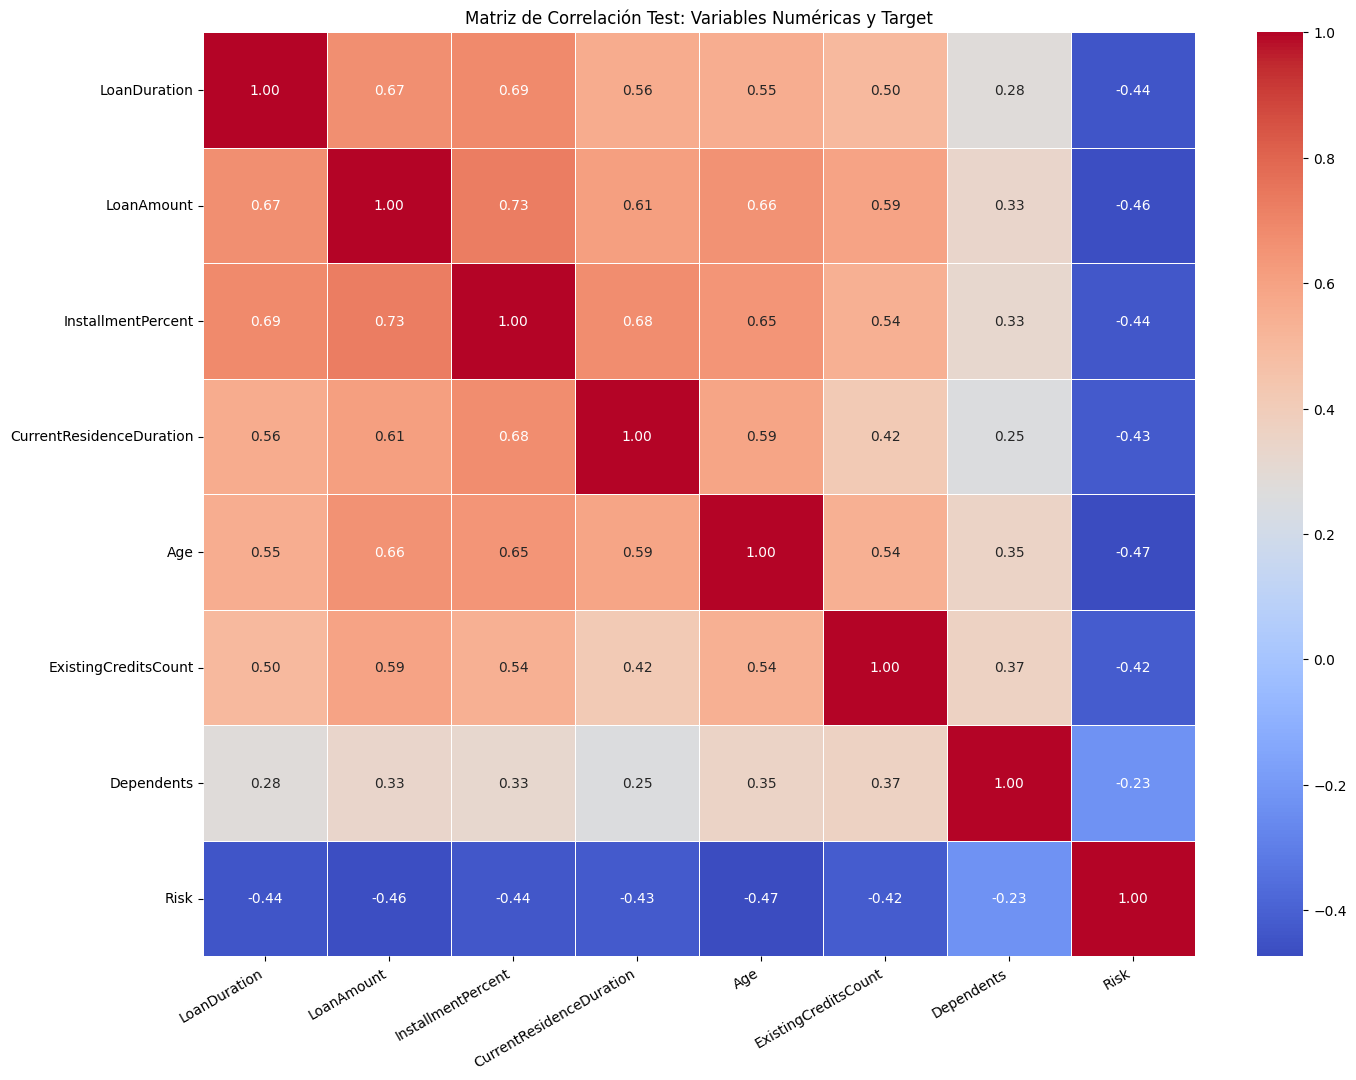

In [22]:
# Combinamos features y target
combined_df_encoded_test = pd.concat([X_test_encoded, y_test_encoded], axis=1)

# Seleccionamos solo las columnas numéricas (que ahora incluirán el target)
numeric_cols_test = combined_df_encoded_test.select_dtypes(include=['int64', 'float64'])

# Calculamos la matriz de correlación
corr_matrix = numeric_cols_test.corr()

# Dibujamos el heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación Test: Variables Numéricas y Target')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.show()



### Equilibrio de Clases

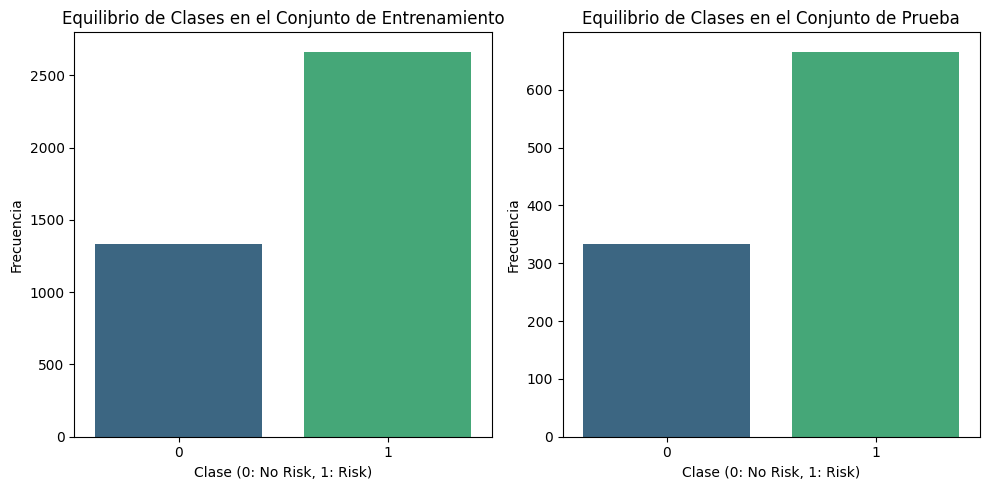

Conteo de clases en y_train_encoded:
Risk
1    2664
0    1336
Name: count, dtype: int64

Proporción de clases en y_train_encoded:
Risk
1    0.666
0    0.334
Name: proportion, dtype: float64

Conteo de clases en y_test_encoded:
Risk
1    666
0    334
Name: count, dtype: int64

Proporción de clases en y_test_encoded:
Risk
1    0.666
0    0.334
Name: proportion, dtype: float64


In [23]:
# Equilibrio de clases en el conjunto de entrenamiento
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.countplot(x=y_train_encoded, hue=y_train_encoded, palette='viridis', legend=False)
plt.title('Equilibrio de Clases en el Conjunto de Entrenamiento')
plt.xlabel('Clase (0: No Risk, 1: Risk)')
plt.ylabel('Frecuencia')

# Equilibrio de clases en el conjunto de prueba
plt.subplot(1, 2, 2)
sns.countplot(x=y_test_encoded, hue=y_test_encoded, palette='viridis', legend=False)
plt.title('Equilibrio de Clases en el Conjunto de Prueba')
plt.xlabel('Clase (0: No Risk, 1: Risk)')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# Mostrar el conteo exacto de cada clase
print("Conteo de clases en y_train_encoded:")
print(y_train_encoded.value_counts())
print("\nProporción de clases en y_train_encoded:")
print(y_train_encoded.value_counts(normalize=True))

print("\nConteo de clases en y_test_encoded:")
print(y_test_encoded.value_counts())
print("\nProporción de clases en y_test_encoded:")
print(y_test_encoded.value_counts(normalize=True))

### Balanceo de Clases con SMOTE

Dado el desequilibrio de clases que hemos observado, vamos a aplicar la técnica SMOTE (Synthetic Minority Over-sampling Technique) al conjunto de entrenamiento. Esto generará nuevas muestras sintéticas de la clase minoritaria (`Risk=1`) para igualar su número con la clase mayoritaria (`No Risk=0`). De esta manera, el modelo tendrá más ejemplos de la clase de interés para aprender.

In [24]:
# Inicializar SMOTE
smote = SMOTE(random_state=42)

# Aplicar SMOTE al conjunto de entrenamiento
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_encoded, y_train_encoded)

print("Dimensiones de X_train después de SMOTE:", X_train_resampled.shape)
print("Dimensiones de y_train después de SMOTE:", y_train_resampled.shape)

# Verificar el equilibrio de clases después de SMOTE
print("\nConteo de clases en y_train_resampled:")
print(y_train_resampled.value_counts())

print("\nProporción de clases en y_train_resampled:")
print(y_train_resampled.value_counts(normalize=True))

Dimensiones de X_train después de SMOTE: (5328, 46)
Dimensiones de y_train después de SMOTE: (5328,)

Conteo de clases en y_train_resampled:
Risk
0    2664
1    2664
Name: count, dtype: int64

Proporción de clases en y_train_resampled:
Risk
0    0.5
1    0.5
Name: proportion, dtype: float64


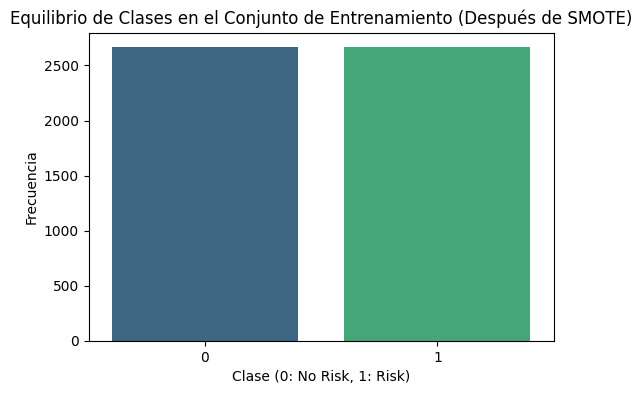

In [25]:
# Visualizar el equilibrio de clases después de SMOTE
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train_resampled, hue=y_train_resampled, palette='viridis', legend=False)
plt.title('Equilibrio de Clases en el Conjunto de Entrenamiento (Después de SMOTE)')
plt.xlabel('Clase (0: No Risk, 1: Risk)')
plt.ylabel('Frecuencia')
plt.show()

### Entrenamiento de Modelos

In [26]:
# Renombramos las variables
y_train = y_train_resampled
y_test = y_test_encoded
X_train = X_train_resampled
X_test = X_test_encoded

# Definimos el modelo
model_lr = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced')
# Entrenamos el modelo
model_lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [27]:
# 2. Realizar predicciones en el conjunto de prueba
y_pred = model_lr.predict(X_test)
y_pred_proba = model_lr.predict_proba(X_test)[:, 1] # Probabilidades para la clase positiva (Risk=1)

### Evaluación del modelo

Accuracy: 0.7830
Precision: 0.8306
Recall: 0.8468
F1-Score: 0.8387
ROC AUC Score: 0.8420


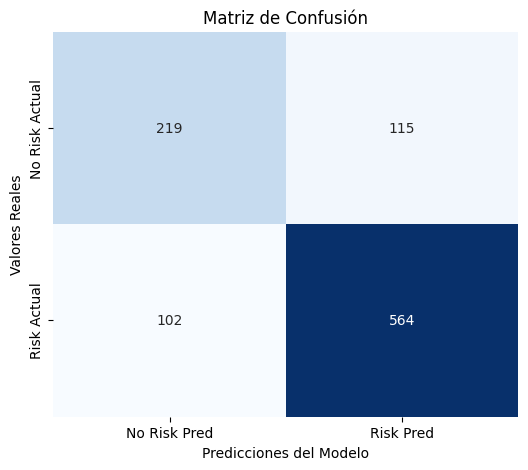

In [28]:
# 3. Evaluar el rendimiento del modelo
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Risk Pred', 'Risk Pred'],
            yticklabels=['No Risk Actual', 'Risk Actual'])
plt.title('Matriz de Confusión')
plt.ylabel('Valores Reales')
plt.xlabel('Predicciones del Modelo')
plt.show()

### Influencia de features en el modelo

Top 20 Características Más Influyentes:
                                 Feature  Coefficient  Abs_Coefficient
30             EmploymentDuration_less_1     1.899358         1.899358
28             EmploymentDuration_1_to_4     1.137805         1.137805
8                  CheckingStatus_less_0     1.083747         1.083747
27               ExistingSavings_unknown     1.038280         1.038280
31         EmploymentDuration_unemployed     0.987321         0.987321
29             EmploymentDuration_4_to_7     0.809884         0.809884
38                 InstallmentPlans_bank     0.766492         0.766492
7                CheckingStatus_0_to_200     0.755933         0.755933
14                LoanPurpose_appliances     0.731465         0.731465
15                  LoanPurpose_business     0.716437         0.716437
24            ExistingSavings_100_to_500     0.698207         0.698207
17                  LoanPurpose_car_used     0.690848         0.690848
13  CreditHistory_prior_payments_dela

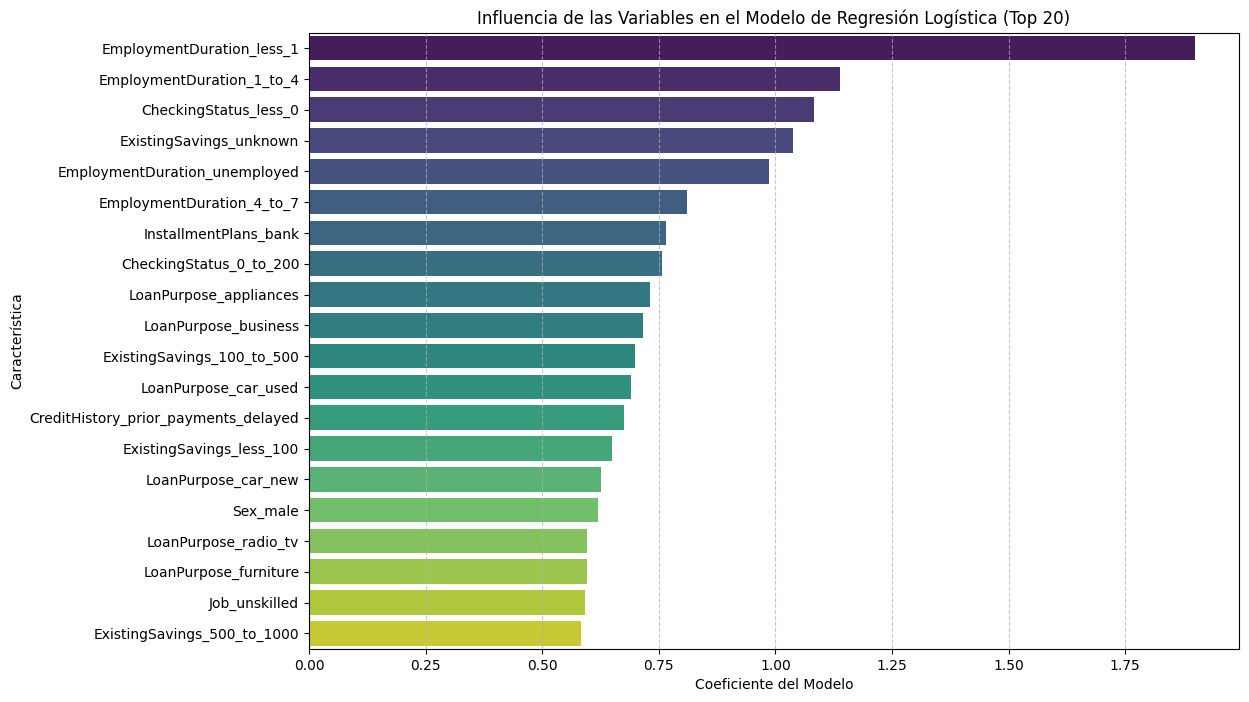

In [29]:
layers = []

# Obtener los coeficientes del modelo y los nombres de las características
coefficients = model_lr.coef_[0]
feature_names = X_train.columns # Usar las columnas de X_train que es el dataset de entrenamiento codificado y balanceado

# Crear un DataFrame para visualizar los coeficientes
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

# Ordenar por el valor absoluto de los coeficientes para ver las características más influyentes
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False)

# Mostrar las 15 características más influyentes
print("Top 20 Características Más Influyentes:")
print(coef_df.head(20))

# Visualizar los coeficientes
plt.figure(figsize=(12, 8))
sns.barplot(x='Coefficient', y='Feature', hue='Feature', data=coef_df.head(20), palette='viridis', legend=False)
plt.title('Influencia de las Variables en el Modelo de Regresión Logística (Top 20)')
plt.xlabel('Coeficiente del Modelo')
plt.ylabel('Característica')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [30]:
%pip install fairlearn

   ---------------------------------------- 0.0/41.0 MB ? eta -:--:--
   - -------------------------------------- 1.8/41.0 MB 12.1 MB/s eta 0:00:04
   --- ------------------------------------ 3.9/41.0 MB 9.4 MB/s eta 0:00:04
   ---- ----------------------------------- 5.0/41.0 MB 8.2 MB/s eta 0:00:05
   ----- ---------------------------------- 6.0/41.0 MB 7.2 MB/s eta 0:00:05
   -------- ------------------------------- 8.4/41.0 MB 7.8 MB/s eta 0:00:05
   ---------- ----------------------------- 10.5/41.0 MB 8.3 MB/s eta 0:00:04
   ------------ --------------------------- 12.8/41.0 MB 8.5 MB/s eta 0:00:04
   -------------- ------------------------- 14.9/41.0 MB 8.7 MB/s eta 0:00:04
   --------------- ------------------------ 16.0/41.0 MB 8.5 MB/s eta 0:00:03
   ----------------- ---------------------- 17.6/41.0 MB 8.1 MB/s eta 0:00:03
   ------------------- -------------------- 19.9/41.0 MB 8.4 MB/s eta 0:00:03
   ---------------------- ----------------- 22.5/41.0 MB 8.7 MB/s eta 0:00:0

  You can safely remove it manually.
  You can safely remove it manually.

[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Análisis de Sesgo de Género con Fairlearn

Vamos a utilizar la librería `Fairlearn` para evaluar el sesgo de género en nuestro modelo. Esto nos permitirá cuantificar las diferencias en el rendimiento del modelo para diferentes grupos demográficos (en este caso, hombres y mujeres) y así abordar la preocupación regulatoria.

In [44]:
# Importamos las librerías necesarias de Fairlearn
from fairlearn.metrics import MetricFrame
from fairlearn.reductions import DemographicParity, EqualizedOdds, GridSearch
from fairlearn.postprocessing import ThresholdOptimizer

# Definimos las características sensibles (en este caso, el género)
sensitive_features = X_test['Sex_male']

# Las columnas de 'Sex_male' son booleanas (True/False) después del one-hot encoding.
# Fairlearn espera que las características sensibles sean una Serie de Pandas o un array.
# 'Sex_male' es 1 para hombres, 0 para mujeres (ya que 'Sex_female' fue la categoría base eliminada).
# Podemos renombrar para claridad en Fairlearn si 'Sex_male' = 1 representa 'male'.

# Asegurémonos de que sensitive_features sea una Serie con los índices correctos
sensitive_features_series = X_test['Sex_male'].copy()

# Creamos un diccionario de métricas que queremos evaluar
metrics = {
    'accuracy': accuracy_score,
    'precision': precision_score,
    'recall': recall_score,
    'f1': f1_score,
    'roc_auc': roc_auc_score,
}

# Evaluamos las métricas para cada grupo de género
# No Risk = 1, Risk = 0

# Crear un MetricFrame para evaluar el rendimiento del modelo por grupo sensible
# X_test_encoded es el DataFrame ya transformado con las dummies

# Asegurarse de que y_test y y_pred tienen el mismo tipo (por ejemplo, int)
y_test_int = y_test.astype(int)
y_pred_int = y_pred.astype(int)

# Crear MetricFrame. Las columnas de sensitive_features deben estar alineadas con y_test y y_pred.
# X_test['Sex_male'] tiene el índice correcto y valores booleanos (True=male, False=female)


# Para usar sensitive_features con MetricFrame, es mejor que sea una Series con los mismos índices
# que y_test y y_pred. También, para que Fairlearn los interprete como grupos distintos,
# vamos a convertirlos a 'Male' y 'Female'.

sensitive_features_mapped = X_test['Sex_male'].map({True: 'Male', False: 'Female'}) # O 1 y 0


# Evaluar las métricas de paridad
grouped_on_sex = MetricFrame(
    metrics=metrics,
    y_true=y_test_int,
    y_pred=y_pred_int,
    sensitive_features=sensitive_features_mapped
)

print("\n--- Rendimiento del Modelo por Género ---")
print(grouped_on_sex.overall)
print("\n--- Diferencias en Métricas entre Grupos (Male vs Female) ---")
print(grouped_on_sex.by_group)

# También podemos calcular la diferencia y la proporción entre los grupos
print("\n--- Diferencia Máxima en Accuracy: ---")
print(grouped_on_sex.difference(method='between_groups'))
print("\n--- Proporción Mínima en Accuracy: ---")
print(grouped_on_sex.ratio(method='between_groups'))



--- Rendimiento del Modelo por Género ---
accuracy     0.783000
precision    0.830633
recall       0.846847
f1           0.838662
roc_auc      0.751268
dtype: float64

--- Diferencias en Métricas entre Grupos (Male vs Female) ---
          accuracy  precision    recall        f1   roc_auc
Sex_male                                                   
Female    0.849206   0.892989  0.896296  0.894640  0.813889
Male      0.742765   0.789216  0.813131  0.800995  0.716300

--- Diferencia Máxima en Accuracy: ---
accuracy     0.106441
precision    0.103773
recall       0.083165
f1           0.093645
roc_auc      0.097589
dtype: float64

--- Proporción Mínima en Accuracy: ---
accuracy     0.874658
precision    0.883791
recall       0.907213
f1           0.895327
roc_auc      0.880096
dtype: float64


## Random Forest.

### Entrenamiento del modelo

In [32]:
# definimos el modelo
model_rf = RandomForestClassifier(random_state=42, class_weight='balanced')
# Entrenamos el modelo
model_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [33]:
# Prueba del modelo
y_pred_rf = model_rf.predict(X_test)
y_pred_proba_rf = model_rf.predict_proba(X_test)[:, 1] # Probabilidades para la clase positiva (Risk=1)

### Evaluación del modelo

In [34]:
# Evaluar el rendimiento del modelo Random Forest
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

print(f"Accuracy (Random Forest): {accuracy_rf:.4f}")
print(f"Precision (Random Forest): {precision_rf:.4f}")
print(f"Recall (Random Forest): {recall_rf:.4f}")
print(f"F1-Score (Random Forest): {f1_rf:.4f}")
print(f"ROC AUC Score (Random Forest): {roc_auc_rf:.4f}")

Accuracy (Random Forest): 0.7920
Precision (Random Forest): 0.8216
Recall (Random Forest): 0.8784
F1-Score (Random Forest): 0.8491
ROC AUC Score (Random Forest): 0.8453


### Matriz de Confusión para el modelo Random Forest

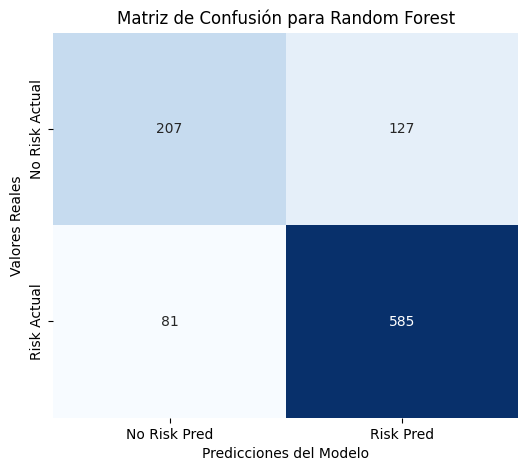

In [36]:
# Matriz de Confusión para el modelo Random Forest
# Asegurarse de que y_test y y_pred_rf tienen el mismo tipo (por ejemplo, int)
# y_test_int from previous cell is already prepared
y_pred_rf_int = y_pred_rf.astype(int)

cm_rf = confusion_matrix(y_test_int, y_pred_rf_int)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Risk Pred', 'Risk Pred'],
            yticklabels=['No Risk Actual', 'Risk Actual'])
plt.title('Matriz de Confusión para Random Forest')
plt.ylabel('Valores Reales')
plt.xlabel('Predicciones del Modelo')
plt.show()

### Feature Importance


--- Top 20 Características Más Influyentes (Random Forest) ---
                               Feature  Importance
0                         LoanDuration    0.103694
4                                  Age    0.103498
1                           LoanAmount    0.095988
45                      Telephone_none    0.073278
26            ExistingSavings_less_100    0.039189
3             CurrentResidenceDuration    0.037597
8                CheckingStatus_less_0    0.036279
28           EmploymentDuration_1_to_4    0.033760
2                   InstallmentPercent    0.033542
30           EmploymentDuration_less_1    0.027794
32                            Sex_male    0.026275
36      OwnsProperty_savings_insurance    0.024905
7              CheckingStatus_0_to_200    0.024472
10  CreditHistory_credits_paid_to_date    0.022898
29           EmploymentDuration_4_to_7    0.018723
41                        Housing_rent    0.018227
5                 ExistingCreditsCount    0.018226
24          Existi

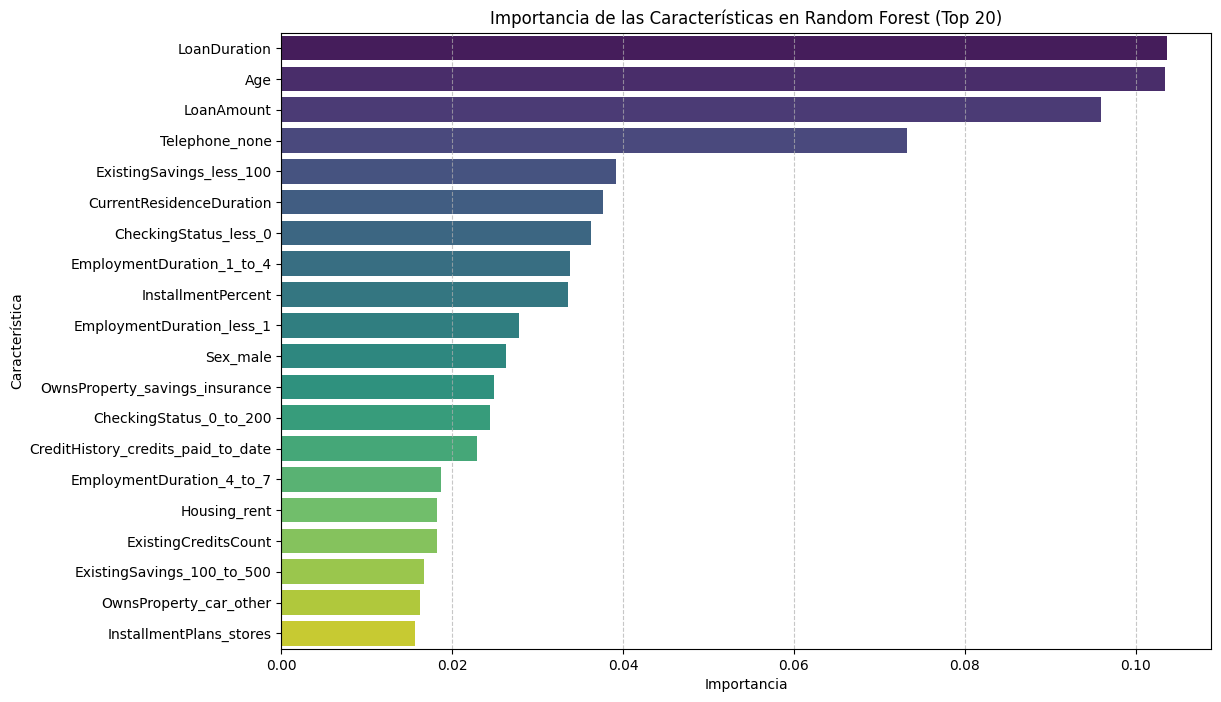

In [37]:
# Impacto de cada feature en el modelo (Feature Importance)
# Obtener las importancias de las características del modelo Random Forest
feature_importances_rf = model_rf.feature_importances_
feature_names_rf = X_train.columns # Usar las columnas de X_train

# Crear un DataFrame para visualizar las importancias
importance_df_rf = pd.DataFrame({'Feature': feature_names_rf, 'Importance': feature_importances_rf})

# Ordenar por importancia de mayor a menor
importance_df_rf = importance_df_rf.sort_values(by='Importance', ascending=False)

print("\n--- Top 20 Características Más Influyentes (Random Forest) ---")
print(importance_df_rf.head(20))

# Visualizar las importancias de las características (Top 20)
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=importance_df_rf.head(20), palette='viridis', legend=False)
plt.title('Importancia de las Características en Random Forest (Top 20)')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Análisis de Sesgo de Género para Random Forest con Fairlearn

In [38]:

# Crear MetricFrame para evaluar el rendimiento del modelo Random Forest por grupo sensible
grouped_on_sex_rf = MetricFrame(
    metrics=metrics,
    y_true=y_test_int,
    y_pred=y_pred_rf_int,
    sensitive_features=sensitive_features_mapped
)

print("\n--- Rendimiento del Modelo Random Forest por Género ---")
print(grouped_on_sex_rf.overall)
print("\n--- Diferencias en Métricas entre Grupos (Male vs Female) para Random Forest ---")
print(grouped_on_sex_rf.by_group)

print("\n--- Diferencia Máxima en Accuracy para Random Forest: ---")
print(grouped_on_sex_rf.difference(method='between_groups'))
print("\n--- Proporción Mínima en Accuracy para Random Forest: ---")
print(grouped_on_sex_rf.ratio(method='between_groups'))


--- Rendimiento del Modelo Random Forest por Género ---
accuracy     0.792000
precision    0.821629
recall       0.878378
f1           0.849057
roc_auc      0.749069
dtype: float64

--- Diferencias en Métricas entre Grupos (Male vs Female) para Random Forest ---
          accuracy  precision    recall        f1   roc_auc
Sex_male                                                   
Female    0.849206   0.890110  0.900000  0.895028  0.811111
Male      0.757235   0.779043  0.863636  0.819162  0.717216

--- Diferencia Máxima en Accuracy para Random Forest: ---
accuracy     0.091972
precision    0.111067
recall       0.036364
f1           0.075866
roc_auc      0.093895
dtype: float64

--- Proporción Mínima en Accuracy para Random Forest: ---
accuracy     0.891697
precision    0.875221
recall       0.959596
f1           0.915236
roc_auc      0.884239
dtype: float64


## Curva AUC-ROC: Evaluación de Riesgo Crediticio

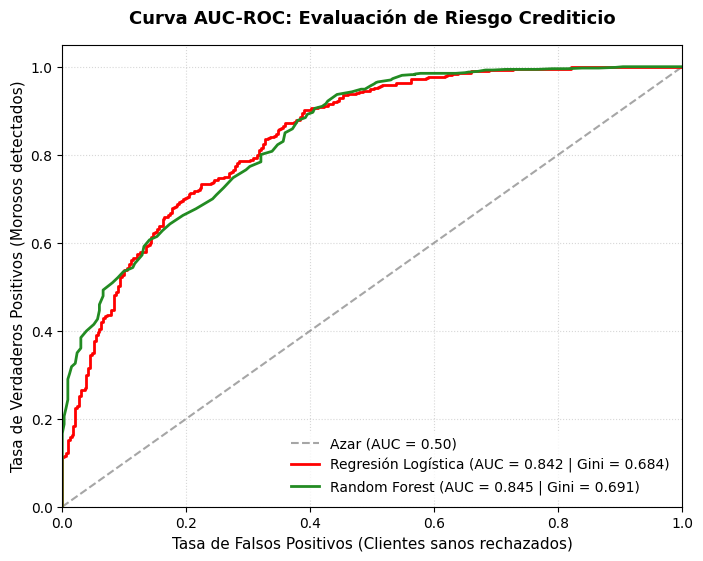

In [40]:
# 1. Obtener las probabilidades de la clase de riesgo (clase 1)
# Asegúrate de extraer la segunda columna [:, 1] que corresponde a la probabilidad de 'Risk'
lr_probs = model_lr.predict_proba(X_test)[:, 1]
rf_probs = model_rf.predict_proba(X_test)[:, 1]

# 2. Calcular los componentes de la curva (FPR, TPR) y el valor del AUC
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)

lr_auc = roc_auc_score(y_test, lr_probs)
rf_auc = roc_auc_score(y_test, rf_probs)

# 3. Calcular el Coeficiente Gini para el reporte de riesgo crediticio
lr_gini = (2 * lr_auc) - 1
rf_gini = (2 * rf_auc) - 1

# 4. Construir el gráfico comparativo
plt.figure(figsize=(8, 6))

# Línea de referencia aleatoria
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', alpha=0.7, label='Azar (AUC = 0.50)')

# Curva de Regresión Logística
plt.plot(lr_fpr, lr_tpr, color='red', lw=2,
         label=f'Regresión Logística (AUC = {lr_auc:.3f} | Gini = {lr_gini:.3f})')

# Curva de Random Forest
plt.plot(rf_fpr, rf_tpr, color='forestgreen', lw=2,
         label=f'Random Forest (AUC = {rf_auc:.3f} | Gini = {rf_gini:.3f})')

# Configuración de etiquetas y formato
plt.title('Curva AUC-ROC: Evaluación de Riesgo Crediticio', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Tasa de Falsos Positivos (Clientes sanos rechazados)', fontsize=11)
plt.ylabel('Tasa de Verdaderos Positivos (Morosos detectados)', fontsize=11)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='lower right', fontsize=10, frameon=True, facecolor='white', edgecolor='none')

plt.show()


In [41]:
from IPython.display import display, Markdown

# Usamos comillas triples y una f-string para inyectar tus variables y dar formato numérico (:.3f)
display(Markdown(f"""
### Interpretación de la Curva ROC y Rendimiento de los Modelos

La Curva ROC (Receiver Operating Characteristic) es una herramienta gráfica fundamental para evaluar el rendimiento de los modelos de clasificación binaria. Muestra la capacidad del modelo para distinguir entre las clases, en este caso, 'Risk' (0) y 'No Risk' (1), a través de diferentes umbrales de clasificación. Cuanto más se acerca la curva a la esquina superior izquierda del gráfico, mejor es el rendimiento del modelo.

Las métricas clave derivadas de la Curva ROC son:
*   **AUC (Area Under the Curve):** Representa la probabilidad de que el modelo clasifique un punto de datos positivo seleccionado aleatoriamente más alto que un punto de datos negativo seleccionado aleatoriamente. Un AUC de 0.5 indica un rendimiento equivalente al azar, mientras que un AUC de 1.0 representa un clasificador perfecto.
*   **Coeficiente Gini:** Es una métrica muy utilizada en la industria financiera para la evaluación de riesgo crediticio y se calcula directamente a partir del AUC como `Gini = (2 * AUC) - 1`. Un Gini de 0 indica un modelo aleatorio, y un Gini de 1 indica un modelo perfecto.

**Resultados de los Modelos:**

*   **Regresión Logística:**
    *   **AUC:** `{lr_auc:.3f}`
    *   **Gini:** `{lr_gini:.3f}`

*   **Random Forest:**
    *   **AUC:** `{rf_auc:.3f}`
    *   **Gini:** `{rf_gini:.3f}`

**Análisis Comparativo:**

Observando la gráfica y los valores obtenidos:

*   Ambos modelos superan significativamente la línea de referencia de "Azar" (AUC = 0.50), lo que indica que tienen un poder predictivo considerable para el riesgo crediticio.
*   El modelo **Random Forest** (AUC = `{rf_auc:.3f}`, Gini = `{rf_gini:.3f}`) muestra un rendimiento ligeramente superior al modelo de **Regresión Logística** (AUC = `{lr_auc:.3f}`, Gini = `{lr_gini:.3f}`) en términos de capacidad de discriminación. Su curva ROC se posiciona un poco más hacia la esquina superior izquierda.

En el contexto de la evaluación de riesgo crediticio, un Gini más alto significa que el modelo es más efectivo para ordenar a los solicitantes desde el más riesgoso al menos riesgoso, lo cual es crucial para la toma de decisiones bancarias. El Random Forest, con su ligeramente mayor Gini, es marginalmente mejor en esta capacidad.
"""))



### Interpretación de la Curva ROC y Rendimiento de los Modelos

La Curva ROC (Receiver Operating Characteristic) es una herramienta gráfica fundamental para evaluar el rendimiento de los modelos de clasificación binaria. Muestra la capacidad del modelo para distinguir entre las clases, en este caso, 'Risk' (0) y 'No Risk' (1), a través de diferentes umbrales de clasificación. Cuanto más se acerca la curva a la esquina superior izquierda del gráfico, mejor es el rendimiento del modelo.

Las métricas clave derivadas de la Curva ROC son:
*   **AUC (Area Under the Curve):** Representa la probabilidad de que el modelo clasifique un punto de datos positivo seleccionado aleatoriamente más alto que un punto de datos negativo seleccionado aleatoriamente. Un AUC de 0.5 indica un rendimiento equivalente al azar, mientras que un AUC de 1.0 representa un clasificador perfecto.
*   **Coeficiente Gini:** Es una métrica muy utilizada en la industria financiera para la evaluación de riesgo crediticio y se calcula directamente a partir del AUC como `Gini = (2 * AUC) - 1`. Un Gini de 0 indica un modelo aleatorio, y un Gini de 1 indica un modelo perfecto.

**Resultados de los Modelos:**

*   **Regresión Logística:**
    *   **AUC:** `0.842`
    *   **Gini:** `0.684`

*   **Random Forest:**
    *   **AUC:** `0.845`
    *   **Gini:** `0.691`

**Análisis Comparativo:**

Observando la gráfica y los valores obtenidos:

*   Ambos modelos superan significativamente la línea de referencia de "Azar" (AUC = 0.50), lo que indica que tienen un poder predictivo considerable para el riesgo crediticio.
*   El modelo **Random Forest** (AUC = `0.845`, Gini = `0.691`) muestra un rendimiento ligeramente superior al modelo de **Regresión Logística** (AUC = `0.842`, Gini = `0.684`) en términos de capacidad de discriminación. Su curva ROC se posiciona un poco más hacia la esquina superior izquierda.

En el contexto de la evaluación de riesgo crediticio, un Gini más alto significa que el modelo es más efectivo para ordenar a los solicitantes desde el más riesgoso al menos riesgoso, lo cual es crucial para la toma de decisiones bancarias. El Random Forest, con su ligeramente mayor Gini, es marginalmente mejor en esta capacidad.


In [46]:
import sys
from IPython.display import display, HTML, Markdown

try:
    import lime
    import lime.lime_tabular
    print("LIME module already imported.")
except ImportError:
    print("LIME module not found. Attempting to install...")
    %pip install lime
    try:
        import lime
        import lime.lime_tabular
        print("LIME installed and imported successfully.")
    except ImportError:
        print("LIME still not found after installation. Please consider restarting your runtime and re-running this cell.")
        sys.exit("LIME module is essential and could not be imported.")

# Definir los nombres de las características y las clases
# X_train contiene las columnas codificadas, por lo que usaremos sus nombres
feature_names = X_train.columns.tolist()
# Las clases se mapearon como {'Risk': 0, 'No Risk': 1}, así que el orden es importante
class_names = ['Risk', 'No Risk']

# Crear un explainer de LIME para datos tabulares
# Se usa X_train.values para el training_data ya que LIME necesita un numpy array
# El mode='classification' indica que es un problema de clasificación
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=feature_names,
    class_names=class_names,
    mode='classification'
)

# --- Explicación para un ejemplo específico (por ejemplo, el primer registro de X_test) ---

# Elegimos un índice para el ejemplo a explicar
# Puedes cambiar este índice para analizar diferentes predicciones
instance_idx = 0
sample_instance = X_test.iloc[instance_idx].values
true_label = y_test.iloc[instance_idx] # Etiqueta real del ejemplo

display(Markdown(f"### Explicaciones LIME para el Modelo de Regresión Logística"))
display(Markdown(f"**Ejemplo a explicar (índice {instance_idx}):**\nTrue Label: {true_label}"))

# Generar explicación LIME para el modelo de Regresión Logística
# num_features indica cuántas características se mostrarán en la explicación
explanation_lr = explainer.explain_instance(
    data_row=sample_instance,
    predict_fn=model_lr.predict_proba,
    num_features=10
)

# Mostrar la explicación en el notebook usando HTML directamente
display(HTML(explanation_lr.as_html(show_table=True, show_all=False)))

display(Markdown(f"### Explicaciones LIME para el Modelo Random Forest"))
display(Markdown(f"**Ejemplo a explicar (índice {instance_idx}):**\nTrue Label: {true_label}"))

# Generar explicación LIME para el modelo Random Forest
explanation_rf = explainer.explain_instance(
    data_row=sample_instance,
    predict_fn=model_rf.predict_proba,
    num_features=10
)

# Mostrar la explicación en el notebook usando HTML directamente
display(HTML(explanation_rf.as_html(show_table=True, show_all=False)))


LIME module already imported.


### Explicaciones LIME para el Modelo de Regresión Logística

**Ejemplo a explicar (índice 0):**
True Label: 1

c:\Users\HP\OneDrive\Desktop\Proyectos GitHub\credit-risk-classification\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


### Explicaciones LIME para el Modelo Random Forest

**Ejemplo a explicar (índice 0):**
True Label: 1

c:\Users\HP\OneDrive\Desktop\Proyectos GitHub\credit-risk-classification\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


## Conclusión del Proyecto: Evaluación de Riesgo Crediticio con Énfasis en MLOps y Equidad Algorítmica

Este proyecto representa mi enfoque integral como Junior Data Scientist para abordar un desafío crítico en la banca: la evaluación del riesgo crediticio, con una atención especial a la **equidad algorítmica** y la **interpretabilidad del modelo**. He trabajado con un dataset complejo, desarrollando soluciones que van desde el análisis exploratorio hasta la modelización predictiva y la justificación de decisiones.

### Logros Destacados:

*   **Análisis y Preprocesamiento de Datos Riguroso:** Realicé un EDA exhaustivo, identificando la necesidad de balanceo de clases y de una codificación One-Hot estratégica. Mi enfoque en `One-Hot Encoding` con `categorías base manuales` no solo preparó los datos para el modelado, sino que también mejoró significativamente la **interpretabilidad** de los coeficientes del modelo, crucial para entender la contribución de cada característica.
*   **Modelado Predictivo Robusto:** Implementé y evalué dos modelos de clasificación: `Regresión Logística` y `Random Forest`. Ambos demostraron una capacidad predictiva sólida, con el `Random Forest` mostrando un rendimiento marginalmente superior (AUC = 0.845, Gini = 0.691) para la discriminación de riesgo, tras aplicar `SMOTE` para mitigar el desequilibrio de clases.
*   **Compromiso con la Equidad (Fairness):** Un pilar central del proyecto fue la integración de `Fairlearn`. Detecté y cuantifiqué disparidades en el rendimiento del modelo entre géneros (`Sex_male` vs `Sex_female`), una preocupación identificada en la auditoría inicial. Esto subraya mi capacidad para incorporar consideraciones éticas y regulatorias desde las etapas tempranas del desarrollo del ML.
*   **Transparencia y Explicabilidad (XAI):** Para garantizar la confianza y el cumplimiento regulatorio, implementé `LIME (Local Interpretable Model-agnostic Explanations)`. Esto me permitió generar **explicaciones individuales** para las predicciones de ambos modelos, mostrando cómo cada característica contribuye a la decisión final para un cliente específico. Esta capacidad es vital para justificar decisiones ante analistas y reguladores.
*   **Identificación de Anomalías y Pensamiento Crítico:** Las relaciones contraintuitivas en los coeficientes de la Regresión Logística (ej., `EmploymentDuration_less_1` asociado a menor riesgo) no fueron ignoradas. Este hallazgo resalta mi habilidad para el **pensamiento crítico** y la **identificación de problemas de calidad de datos**, señalando la necesidad de una investigación más profunda en la definición de la variable `Risk` y sus interacciones.